# Resultados del modelado — Wine Quality

Análisis de los experimentos de `run_experimentos.py` (Entregable 2). Cada fila de los logs es un **fold externo** de una validación cruzada anidada, así que todas las métricas de este notebook están medidas sobre datos que la búsqueda de hiperparámetros nunca vio.

| | Clasificación (`quality ≥ 7`) | Regresión (`quality`) |
|---|---|---|
| Modelos | KNN, Naive Bayes, Regresión logística, Árbol de decisión, Random Forest, XGBoost, SVM | KNN, Ridge, Lasso, Árbol de decisión, Random Forest, XGBoost, SVR |
| Balanceo | sin balanceo, `class_weight`, SMOTE, ADASYN | no aplica |
| Optimizadores | Grid Search, Random Search, Bayesiano (TPE), Genético | los mismos |
| Validación | 5 folds externos estratificados × 3 internos | 5 × 3 |
| Métrica que optimiza la búsqueda | AUC-ROC | RMSE |
| Registros | 108 combinaciones × 5 folds = 540 | 28 combinaciones × 5 folds = 140 |

Presupuesto: 40 evaluaciones por búsqueda (Grid Search usa una grilla adaptativa de 24 a 40 puntos). Datos: 5,320 vinos únicos tras quitar duplicados, 19% de ellos "buenos".

Las figuras se guardan en `experiments/figures/` y las tablas en `experiments/tablas/`.

In [4]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch, Patch, Rectangle
from matplotlib.transforms import offset_copy
from scipy import stats
from sklearn.model_selection import KFold
from IPython.display import display

%matplotlib inline

# Carpeta modelado/ (la que contiene src/ y experiments/), sin importar desde dónde se abra el notebook
RUTA_MODELADO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
if str(RUTA_MODELADO) not in sys.path:
    sys.path.insert(0, str(RUTA_MODELADO))

from src import config
from src.data_prep import preparar_dataset, separar_X_y

RUTA_TABLAS = config.RUTA_EXPERIMENTOS / "tablas"
RUTA_TABLAS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 140)
for nombre, ruta in [("Logs", config.RUTA_LOGS), ("Figuras", config.RUTA_FIGURAS), ("Tablas", RUTA_TABLAS)]:
    print(f"{nombre:8s} {ruta.relative_to(RUTA_MODELADO)}")

Logs     experiments\logs
Figuras  experiments\figures
Tablas   experiments\tablas


In [5]:
# ---------------------------------------------------------------------------
# Estilo de las gráficas: tinta neutra, grilla tenue y una paleta categórica
# validada para daltonismo (azul / naranja / aqua; gris para la referencia).
# ---------------------------------------------------------------------------
TINTA, TINTA_2, TINTA_3 = "#0b0b0b", "#52514e", "#898781"   # texto principal / secundario / atenuado
GRILLA, EJE, FONDO = "#e1e0d9", "#c3c2b7", "#ffffff"
AZUL, NARANJA, AQUA, ROJO = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
GRIS_NEUTRO = "#f0efec"
CMAP_SECUENCIAL = mcolors.LinearSegmentedColormap.from_list(
    "azules", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
CMAP_DIVERGENTE = mcolors.LinearSegmentedColormap.from_list("rojo_gris_azul", [ROJO, GRIS_NEUTRO, AZUL])

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight", "savefig.pad_inches": 0.2,
    "figure.facecolor": FONDO, "axes.facecolor": FONDO, "savefig.facecolor": FONDO,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "text.color": TINTA,
    "axes.edgecolor": EJE, "axes.linewidth": 0.8, "axes.labelcolor": TINTA_2, "axes.labelsize": 9.5,
    "axes.titlesize": 10.5, "axes.titleweight": "semibold", "axes.titlecolor": TINTA,
    "axes.titlelocation": "left", "axes.titlepad": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2, "xtick.labelsize": 9, "ytick.labelsize": 9.5,
    "xtick.major.size": 0, "ytick.major.size": 0, "xtick.major.pad": 5, "ytick.major.pad": 6,
    "grid.color": GRILLA, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "legend.frameon": False, "legend.fontsize": 9, "legend.handletextpad": 0.5, "legend.columnspacing": 1.6,
})

NOMBRE_CORTO = {"Regresión Logística (L1/L2)": "Reg. logística", "sin_balanceo": "Sin balanceo"}
BALANCEOS = ["sin_balanceo", "class_weight", "SMOTE", "ADASYN"]
ETIQUETA_BALANCEO = {"sin_balanceo": "Sin balanceo", "class_weight": "class_weight",
                     "SMOTE": "SMOTE", "ADASYN": "ADASYN"}
COLOR_BALANCEO = {"sin_balanceo": TINTA_3, "class_weight": AZUL, "SMOTE": NARANJA, "ADASYN": AQUA}
OPTIMIZADORES = ["Grid Search", "Random Search", "Bayesiano", "Genético"]


def corto(nombre):
    return NOMBRE_CORTO.get(nombre, nombre)


def mas_menos(media, de, decimales=3):
    return f"{media:.{decimales}f} ± {de:.{decimales}f}"


def guardar(fig, nombre):
    fig.savefig(config.RUTA_FIGURAS / f"{nombre}.png")


def guardar_tabla(tabla, nombre):
    tabla.to_csv(RUTA_TABLAS / f"{nombre}.csv", index=False)


def encabezado(fig, titulo, subtitulo=None):
    """Titular (el hallazgo) y subtítulo (qué se grafica), alineados al borde
    izquierdo de todo lo que ya está dibujado en la figura."""
    fig.canvas.draw()
    caja = fig.get_tightbbox(fig.canvas.get_renderer())      # en pulgadas
    ancho, alto = fig.get_size_inches()
    x, y = caja.x0 / ancho, caja.y1 / alto
    desplazamiento = 8
    if subtitulo:
        fig.text(x, y, subtitulo, ha="left", va="bottom", fontsize=9.5, color=TINTA_2, linespacing=1.45,
                 transform=offset_copy(fig.transFigure, fig=fig, y=desplazamiento, units="points"))
        desplazamiento += 9.5 * 1.45 * (subtitulo.count("\n") + 1) + 5
    fig.text(x, y, titulo, ha="left", va="bottom", fontsize=13.5, fontweight="semibold", color=TINTA,
             transform=offset_copy(fig.transFigure, fig=fig, y=desplazamiento, units="points"))


def barra_redondeada(ax, x, ancho, alto, color, radio_pt=3.0):
    """Barra vertical con el extremo del dato redondeado y la base recta.
    Llamar después de fijar límites y layout (fig.canvas.draw())."""
    caja = ax.get_window_extent()
    (x0, x1), (y0, y1) = ax.get_xlim(), ax.get_ylim()
    radio_px = radio_pt * ax.figure.dpi / 72
    rx = radio_px * (x1 - x0) / caja.width
    ry = min(radio_px * (y1 - y0) / caja.height, alto / 2)
    ax.add_patch(FancyBboxPatch((x - ancho / 2, 0), ancho, alto, boxstyle=f"round,pad=0,rounding_size={rx}",
                                mutation_aspect=ry / rx, facecolor=color, edgecolor="none", zorder=3))
    ax.add_patch(Rectangle((x - ancho / 2, 0), ancho, alto - ry, facecolor=color, edgecolor="none", zorder=3))


def luminancia(color):
    canales = [c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4 for c in mcolors.to_rgb(color)]
    return 0.2126 * canales[0] + 0.7152 * canales[1] + 0.0722 * canales[2]


def mapa_calor(ax, tabla, cmap, norm, formato, negrita=None, texto_na="no aplica"):
    """Mapa de calor anotado: el texto de cada celda va en tinta o en blanco
    según el fondo, y un filo de 2.5 px del color de fondo separa las celdas."""
    datos = tabla.to_numpy(dtype=float)
    filas, columnas = datos.shape
    ax.imshow(np.ma.masked_invalid(datos), cmap=cmap, norm=norm, aspect="auto")
    for i in range(filas):
        for j in range(columnas):
            valor = datos[i, j]
            if np.isnan(valor):
                ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=GRIS_NEUTRO, edgecolor="none"))
                ax.text(j, i, texto_na, ha="center", va="center", fontsize=8.5, color=TINTA_3)
                continue
            ax.text(j, i, formato(valor), ha="center", va="center", fontsize=9.5,
                    color=FONDO if luminancia(cmap(norm(valor))) < 0.18 else TINTA,
                    fontweight="bold" if negrita is not None and negrita[i, j] else "normal")
    ax.set_xticks(range(columnas), labels=tabla.columns)
    ax.set_yticks(range(filas), labels=tabla.index)
    ax.set_xticks(np.arange(1, columnas) - 0.5, minor=True)
    ax.set_yticks(np.arange(1, filas) - 0.5, minor=True)
    ax.grid(which="minor", color=FONDO, linewidth=2.5)
    ax.tick_params(which="both", length=0)
    ax.tick_params(axis="y", labelcolor=TINTA)
    ax.xaxis.tick_top()
    for lado in ax.spines.values():
        lado.set_visible(False)


def barra_color(fig, ax, cmap, norm, etiqueta, formato=None):
    barra = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation="horizontal",
                         location="bottom", shrink=0.8, aspect=35, pad=0.03, format=formato)
    barra.outline.set_visible(False)
    barra.ax.tick_params(labelsize=8.5, colors=TINTA_2, length=0)
    barra.set_label(etiqueta, fontsize=9, color=TINTA_2)
    return barra


def friedman_nemenyi(df, tratamiento, bloques, metrica, mayor_es_mejor=True, alfa=0.05):
    """Test de Friedman (con la corrección de Iman-Davenport) y diferencia crítica
    de Nemenyi (Demšar, 2006). Cada bloque es una fila de la tabla ancha, p. ej.
    un fold externo con balanceo y optimizador fijos; dentro de cada bloque se
    ordenan los tratamientos (1 = mejor)."""
    ancha = df.pivot_table(index=bloques, columns=tratamiento, values=metrica).dropna()
    rangos = (-ancha if mayor_es_mejor else ancha).rank(axis=1, method="average")
    N, k = ancha.shape
    chi2, p = stats.friedmanchisquare(*[ancha[c] for c in ancha.columns])
    f_id = (N - 1) * chi2 / (N * (k - 1) - chi2)
    p_id = stats.f.sf(f_id, k - 1, (k - 1) * (N - 1))
    q_alfa = stats.studentized_range.ppf(1 - alfa, k, np.inf) / np.sqrt(2)
    cd = q_alfa * np.sqrt(k * (k + 1) / (6 * N))
    return {"rangos": rangos.mean().sort_values(), "cd": cd, "N": N, "k": k,
            "chi2": chi2, "p": p, "F_ID": f_id, "p_ID": p_id}


def grupos_sin_diferencia(rangos, cd):
    """Intervalos maximales de tratamientos (ordenados por rango) cuya diferencia
    de rango promedio es menor que la CD: no se distinguen entre sí."""
    valores, grupos = rangos.to_numpy(), []
    for i in range(len(valores)):
        j = i
        while j + 1 < len(valores) and valores[j + 1] - valores[i] < cd:
            j += 1
        if j > i and not any(a <= i and j <= b for a, b in grupos):
            grupos.append((i, j))
    return grupos


def diagrama_cd(ax, resultado, fuente=10):
    """Diagrama de diferencia crítica: eje de rangos promedio (1 = mejor), la barra
    CD arriba y, en azul, los grupos que el test de Nemenyi no logra separar."""
    rangos, cd = resultado["rangos"], resultado["cd"]
    k, nombres = len(rangos), [corto(n) for n in rangos.index]
    ax.axis("off")
    ax.figure.canvas.draw()
    ancho_pulg = ax.get_window_extent().width / ax.figure.dpi
    largo = max(len(f"{n}  {r:.2f}") for n, r in zip(nombres, rangos)) * fuente * 0.55 / 72
    margen = largo * (k - 1 + 0.9) / max(ancho_pulg - 2 * largo, 0.5) + 0.45
    ax.set_xlim(1 - margen, k + margen)

    ax.plot([1, k], [0, 0], color=TINTA_2, lw=1)
    for t in range(1, k + 1):
        ax.plot([t, t], [0, 0.07], color=TINTA_2, lw=1)
        ax.text(t, 0.12, str(t), ha="center", va="bottom", fontsize=9, color=TINTA_2)
    y_cd = 0.62
    ax.plot([1, 1 + cd], [y_cd, y_cd], color=TINTA, lw=1.5)
    for extremo in (1, 1 + cd):
        ax.plot([extremo, extremo], [y_cd - 0.06, y_cd + 0.06], color=TINTA, lw=1.5)
    ax.text(1 + cd / 2, y_cd + 0.1, f"CD = {cd:.2f}", ha="center", va="bottom", fontsize=9, color=TINTA)

    grupos = grupos_sin_diferencia(rangos, cd)
    for g, (a, b) in enumerate(grupos):
        y = -0.2 - 0.14 * g
        ax.plot([rangos.iloc[a] - 0.05, rangos.iloc[b] + 0.05], [y, y], color=AZUL, lw=4,
                solid_capstyle="round", zorder=4)

    y0, paso, mitad = -0.2 - 0.14 * max(len(grupos), 1) - 0.12, 0.3, (k + 1) // 2
    izquierda = list(zip(nombres[:mitad], rangos.iloc[:mitad]))
    derecha = list(zip(nombres[mitad:], rangos.iloc[mitad:]))[::-1]
    for j, (nombre, r) in enumerate(izquierda):
        y = y0 - paso * j
        ax.plot([r, r, 1 - 0.3], [0, y, y], color=TINTA_2, lw=1)
        ax.text(1 - 0.38, y, f"{nombre}  {r:.2f}", ha="right", va="center", fontsize=fuente, color=TINTA)
    for j, (nombre, r) in enumerate(derecha):
        y = y0 - paso * j
        ax.plot([r, r, k + 0.3], [0, y, y], color=TINTA_2, lw=1)
        ax.text(k + 0.38, y, f"{r:.2f}  {nombre}", ha="left", va="center", fontsize=fuente, color=TINTA)
    ax.set_ylim(y0 - paso * (max(len(izquierda), len(derecha)) - 1) - 0.25, y_cd + 0.4)


def grafico_por_modelo(combos, elegidos, metrica, etiqueta_eje, detalle, mayor_es_mejor=True, referencia=None):
    """Una fila por modelo. Gris: cada combinación probada (media de sus 5 folds
    externos). Azul: la combinación con mejor score interno, con ±1 d.e. entre folds."""
    orden = elegidos.sort_values(metrica, ascending=not mayor_es_mejor)["modelo"].tolist()
    n = len(orden)
    fig, (ax, ax_txt) = plt.subplots(1, 2, figsize=(10, 0.5 * n + 1.5), width_ratios=[2.35, 1.25],
                                     sharey=True, layout="constrained")
    rng = np.random.default_rng(7)
    for fila, modelo in enumerate(orden):
        y = n - 1 - fila
        valores = combos.loc[combos["modelo"] == modelo, metrica].to_numpy()
        ax.scatter(valores, y + rng.uniform(-0.17, 0.17, len(valores)), s=26, color=TINTA_3, alpha=0.5,
                   edgecolor=FONDO, linewidth=0.8, zorder=2)
        e = elegidos.loc[elegidos["modelo"] == modelo].iloc[0]
        ax.errorbar(e[metrica], y, xerr=e[f"{metrica}_std"], fmt="o", ms=8, color=AZUL, mec=FONDO,
                    mew=1.5, elinewidth=2, capsize=0, zorder=3)
        ax_txt.text(0.0, y, mas_menos(e[metrica], e[f"{metrica}_std"]), va="center", fontsize=9, color=TINTA)
        ax_txt.text(0.4, y, detalle(e), va="center", fontsize=9, color=TINTA_2)
    ax_txt.text(0.0, n - 0.35, "media ± d.e.", va="bottom", fontsize=8.5, color=TINTA_3)
    ax_txt.text(0.4, n - 0.35, "combinación elegida", va="bottom", fontsize=8.5, color=TINTA_3)
    ax_txt.set_xlim(0, 1)
    ax_txt.axis("off")

    ax.set_yticks(range(n), labels=[corto(m) for m in orden[::-1]])
    ax.tick_params(axis="y", labelcolor=TINTA, labelsize=10)
    ax.set_ylim(-0.6, n + 0.15)
    ax.grid(axis="x")
    ax.set_axisbelow(True)
    ax.spines["left"].set_visible(False)
    ax.set_xlabel(etiqueta_eje)
    ax.margins(x=0.06)
    if referencia is not None:
        valor, texto = referencia
        ax.axvline(valor, color=TINTA_3, lw=1, zorder=1)
        ax.text(valor, n - 0.2, texto + "  ", ha="right", va="center", fontsize=8.5, color=TINTA_2)
    leyenda = [
        Line2D([], [], ls="", marker="o", ms=6, color=TINTA_3, alpha=0.6, mec=FONDO,
               label="Cada combinación probada (media de 5 folds)"),
        Line2D([], [], color=AZUL, lw=2, marker="o", ms=8, mec=FONDO, mew=1.5,
               label="Combinación con mejor score interno (media ± 1 d.e.)"),
    ]
    # una columna: la leyenda queda más angosta que el eje y no desplaza la columna de texto
    ax.legend(handles=leyenda, loc="lower left", bbox_to_anchor=(0, 1.02), borderaxespad=0)
    return fig, ax

## 1. Carga y verificación de los logs

In [6]:
clf = pd.read_csv(config.RUTA_LOG_CLASIFICACION)
reg = pd.read_csv(config.RUTA_LOG_REGRESION)


def verificar(df):
    claves = ["modelo", "balanceo", "optimizador"]
    folds = df.groupby(claves)["fold_externo"].nunique()
    return pd.Series(dtype=object, data={
        "Filas (folds externos)": len(df),
        "Combinaciones": len(folds),
        f"Combinaciones con sus {config.K_OUTER} folds": int((folds == config.K_OUTER).sum()),
        "Filas duplicadas": int(df.duplicated(claves + ["fold_externo"]).sum()),
        "Horas de cómputo (suma de folds)": round(df["tiempo_seg"].sum() / 3600, 1),
    })


display(pd.DataFrame({"Clasificación": verificar(clf), "Regresión": verificar(reg)}))

,Clasificación,Regresión
Filas (folds externos),540,140
Combinaciones,108,28
Combinaciones con sus 5 folds,108,28
Filas duplicadas,0,0
Horas de cómputo (suma de folds),13.5,3.1


Los logs de regresión guardan RMSE y MAE. Como los folds externos son deterministas (`KFold(shuffle=True, random_state=42)` sobre los datos sin duplicados), se pueden reconstruir para calcular el **R² exacto** de cada fold, R² = 1 − RMSE² / Var(y<sub>test</sub>), y el error de una **línea base** que siempre predice la media del train.

In [7]:
df = preparar_dataset(verbose=False)
X, y_reg, y_clf = separar_X_y(df)
folds_reg = list(KFold(n_splits=config.K_OUTER, shuffle=True, random_state=config.RANDOM_STATE).split(X, y_reg))

var_test = {i: y_reg.iloc[te].var(ddof=0) for i, (_, te) in enumerate(folds_reg)}
reg["r2"] = 1 - reg["rmse"] ** 2 / reg["fold_externo"].map(var_test)

RMSE_BASE = np.mean([np.sqrt(((y_reg.iloc[te] - y_reg.iloc[tr].mean()) ** 2).mean()) for tr, te in folds_reg])
PREVALENCIA = y_clf.mean()
print(f"Vinos únicos: {len(df):,} | vinos buenos (quality ≥ {config.UMBRAL_CLASIFICACION}): {PREVALENCIA:.1%}")
print(f"Línea base de regresión (predecir la media del train): RMSE = {RMSE_BASE:.3f}")

Vinos únicos: 5,320 | vinos buenos (quality ≥ 7): 19.0%
Línea base de regresión (predecir la media del train): RMSE = 0.880


In [8]:
METRICAS_CLF = ["auc", "f1", "recall", "precision", "accuracy"]
METRICAS_REG = ["rmse", "mae", "r2"]


def resumir(df, claves, metricas):
    """Media y desviación estándar entre los folds externos de cada combinación."""
    g = df.groupby(claves)
    resumen = g[metricas].mean().join(g[metricas].std().add_suffix("_std"))
    resumen["score_interno"] = g["score_interno"].mean()
    resumen["n_evaluaciones"] = g["n_evaluaciones"].mean()
    resumen["tiempo_fold_s"] = g["tiempo_seg"].mean()
    return resumen.reset_index()


def elegir_por_score_interno(combos):
    """Para cada modelo, la combinación con mejor score interno medio: es la que
    se elegiría sin mirar los folds externos de prueba."""
    return (combos.sort_values("score_interno", ascending=False)
                  .groupby("modelo").head(1).reset_index(drop=True))


combos_clf = resumir(clf, ["modelo", "balanceo", "optimizador"], METRICAS_CLF)
combos_reg = resumir(reg, ["modelo", "optimizador"], METRICAS_REG)
elegidos_clf = elegir_por_score_interno(combos_clf).sort_values("auc", ascending=False)
elegidos_reg = elegir_por_score_interno(combos_reg).sort_values("rmse")
ORDEN_CLF = elegidos_clf["modelo"].tolist()     # mismo orden de filas en todas las figuras
ORDEN_REG = elegidos_reg["modelo"].tolist()

## 2. Clasificación: ¿qué modelo distingue mejor los vinos buenos?

Cada punto gris es una combinación balanceo × optimizador (media de sus 5 folds externos). El punto azul es la combinación que se elegiría **sin mirar los folds de prueba** —la de mejor score interno— con su variación entre folds (±1 desviación estándar).

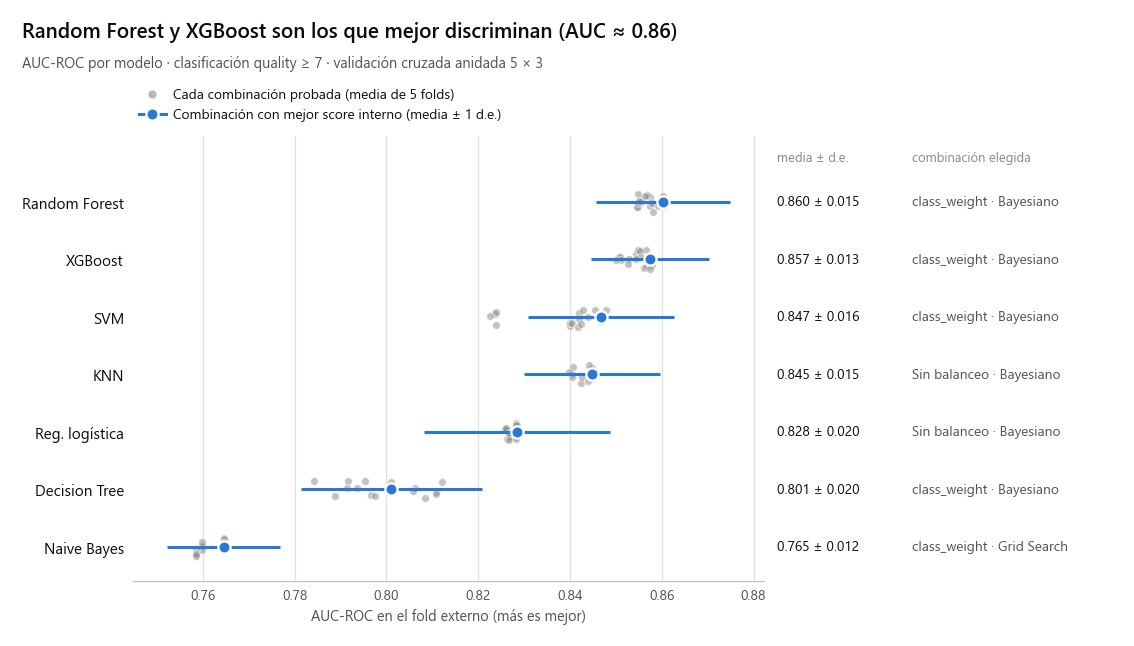

In [9]:
def detalle_clf(fila):
    return f"{ETIQUETA_BALANCEO[fila['balanceo']]} · {fila['optimizador']}"


fig, ax = grafico_por_modelo(combos_clf, elegidos_clf, "auc", "AUC-ROC en el fold externo (más es mejor)", detalle_clf)
encabezado(fig, "Random Forest y XGBoost son los que mejor discriminan (AUC ≈ 0.86)",
           "AUC-ROC por modelo · clasificación quality ≥ 7 · validación cruzada anidada 5 × 3")
guardar(fig, "fig01_clf_auc_por_modelo")
plt.show()

In [10]:
tabla01 = elegidos_clf[["modelo", "balanceo", "optimizador", "auc", "auc_std", "f1", "f1_std", "recall",
                        "precision", "accuracy", "score_interno", "tiempo_fold_s"]].round(4)
guardar_tabla(tabla01, "tabla01_clf_mejor_config_por_modelo")

display(pd.DataFrame({
    "Balanceo": elegidos_clf["balanceo"].map(ETIQUETA_BALANCEO).to_numpy(),
    "Optimizador": elegidos_clf["optimizador"].to_numpy(),
    "AUC-ROC": [mas_menos(m, s) for m, s in zip(elegidos_clf["auc"], elegidos_clf["auc_std"])],
    "F1": [mas_menos(m, s) for m, s in zip(elegidos_clf["f1"], elegidos_clf["f1_std"])],
    "Recall": elegidos_clf["recall"].round(3).to_numpy(),
    "Precisión": elegidos_clf["precision"].round(3).to_numpy(),
    "Accuracy": elegidos_clf["accuracy"].round(3).to_numpy(),
    "Seg. por fold": elegidos_clf["tiempo_fold_s"].round().astype(int).to_numpy(),
}, index=pd.Index(elegidos_clf["modelo"].map(corto), name="Modelo")))

,Balanceo,Optimizador,AUC-ROC,F1,Recall,Precisión,Accuracy,Seg. por fold
Modelo,,,,,,,,
Random Forest,class_weight,Bayesiano,0.860 ± 0.015,0.480 ± 0.051,0.385,0.653,0.844,261
XGBoost,class_weight,Bayesiano,0.857 ± 0.013,0.559 ± 0.026,0.614,0.517,0.817,191
SVM,class_weight,Bayesiano,0.847 ± 0.016,0.548 ± 0.017,0.817,0.413,0.744,63
KNN,Sin balanceo,Bayesiano,0.845 ± 0.015,0.436 ± 0.035,0.333,0.636,0.837,16
Reg. logística,Sin balanceo,Bayesiano,0.828 ± 0.020,0.384 ± 0.025,0.290,0.572,0.823,12
Decision Tree,class_weight,Bayesiano,0.801 ± 0.020,0.505 ± 0.021,0.781,0.374,0.709,5
Naive Bayes,class_weight,Grid Search,0.765 ± 0.012,0.444 ± 0.016,0.778,0.310,0.630,3


> **Resultado:** los dos ensambles de árboles encabezan la tabla: Random Forest (AUC 0.860 ± 0.015) y XGBoost (0.857 ± 0.013), seguidos de SVM y KNN (≈ 0.845); Naive Bayes queda último (0.765). Dentro de cada modelo, sus 12–16 combinaciones de balanceo y optimizador (puntos grises) quedan muy juntas, mientras que entre modelos hay saltos claros: **la familia de modelo pesa más que la forma de ajustarlo**. La variación entre folds (± 0.015) es mayor que la diferencia entre los dos primeros, por eso conviene contrastarlo con un test estadístico. Ojo con la tabla: Random Forest con `class_weight` es el que mejor ordena (AUC más alto), pero con el umbral 0.5 detecta menos del 40% de los vinos buenos.

### 2.1 ¿Las diferencias son significativas? Friedman + Nemenyi

Se usa el test de **Friedman** (no paramétrico, por rangos) con el post-hoc de **Nemenyi** (Demšar, 2006). Cada *bloque* es un fold externo con balanceo y optimizador fijos: 3 balanceos × 4 optimizadores × 5 folds = 60 bloques (se excluye `class_weight` porque KNN no lo admite). Dentro de cada bloque los 7 modelos se ordenan del 1 (mejor AUC) al 7. En el diagrama de diferencia crítica (CD), los modelos unidos por una barra azul **no** difieren significativamente.

Los bloques que comparten fold no son del todo independientes, así que los p-valores son aproximados; las diferencias con p ≪ 0.001 no dependen de ese detalle.

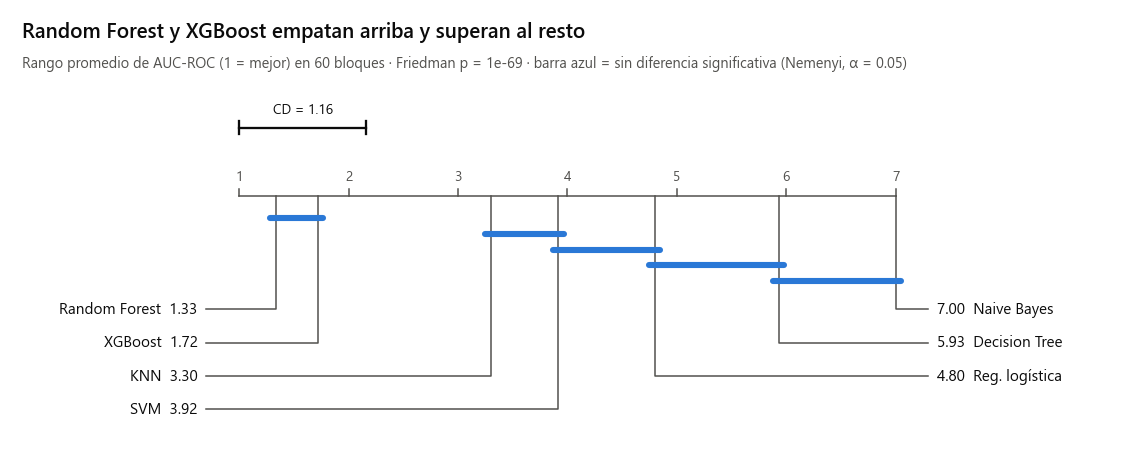

In [11]:
fr_modelos_clf = friedman_nemenyi(clf[clf["balanceo"] != "class_weight"], "modelo",
                                  ["balanceo", "optimizador", "fold_externo"], "auc")

fig, ax = plt.subplots(figsize=(10, 3.3), layout="constrained")
diagrama_cd(ax, fr_modelos_clf)
encabezado(fig, "Random Forest y XGBoost empatan arriba y superan al resto",
           f"Rango promedio de AUC-ROC (1 = mejor) en {fr_modelos_clf['N']} bloques · "
           f"Friedman p = {fr_modelos_clf['p']:.0e} · barra azul = sin diferencia significativa (Nemenyi, α = 0.05)")
guardar(fig, "fig02_clf_cd_modelos")
plt.show()

> **Resultado:** Friedman rechaza que los siete modelos rindan igual (p ≈ 10⁻⁶⁹). Random Forest (rango 1.33) y XGBoost (1.72) están a menos de una diferencia crítica (CD = 1.16), así que **no se puede afirmar que uno supere al otro**; ambos sí son significativamente mejores que los otros cinco. Del tercer lugar hacia abajo, los modelos forman una escalera de grupos solapados (KNN ≈ SVM ≈ Reg. logística ≈ árbol ≈ Naive Bayes, cada uno empatado solo con sus vecinos). Con F1 en lugar de AUC, Random Forest y XGBoost siguen siendo el grupo líder.

## 3. Clasificación: efecto del balanceo de clases

Con solo 19% de vinos buenos, el umbral por defecto (0.5) favorece a la clase mayoritaria. La figura promedia los 6 modelos que admiten las cuatro técnicas (KNN no tiene `class_weight`), los 4 optimizadores y los 5 folds, así que cada barra resume 120 folds externos.

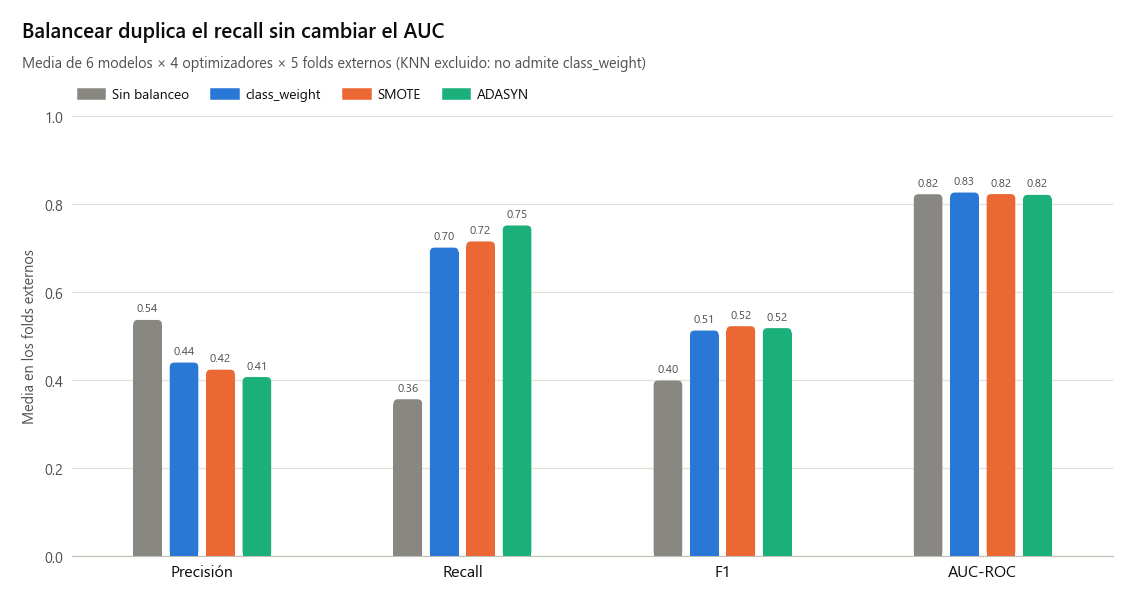

In [12]:
sin_knn = clf[clf["modelo"] != "KNN"]
efecto = sin_knn.groupby("balanceo")[["precision", "recall", "f1", "auc", "accuracy"]].mean().loc[BALANCEOS]
METRICAS_BALANCEO = {"precision": "Precisión", "recall": "Recall", "f1": "F1", "auc": "AUC-ROC"}

fig, ax = plt.subplots(figsize=(10, 4.6), layout="constrained")
ancho, paso = 0.11, 0.14
ax.set_xlim(-0.5, len(METRICAS_BALANCEO) - 0.5)
ax.set_ylim(0, 1)
ax.set_xticks(range(len(METRICAS_BALANCEO)), labels=list(METRICAS_BALANCEO.values()))
ax.tick_params(axis="x", labelsize=10.5, labelcolor=TINTA)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.set_ylabel("Media en los folds externos")
ax.legend(handles=[Patch(color=COLOR_BALANCEO[b], label=ETIQUETA_BALANCEO[b]) for b in BALANCEOS],
          loc="lower left", bbox_to_anchor=(0, 1.02), ncols=4, borderaxespad=0)
fig.canvas.draw()   # fija el layout antes de calcular el redondeo de las barras
for i, metrica in enumerate(METRICAS_BALANCEO):
    for j, balanceo in enumerate(BALANCEOS):
        x, valor = i + (j - 1.5) * paso, efecto.loc[balanceo, metrica]
        barra_redondeada(ax, x, ancho, valor, COLOR_BALANCEO[balanceo])
        ax.text(x, valor + 0.012, f"{valor:.2f}", ha="center", va="bottom", fontsize=7.5, color=TINTA_2)
encabezado(fig, "Balancear duplica el recall sin cambiar el AUC",
           "Media de 6 modelos × 4 optimizadores × 5 folds externos (KNN excluido: no admite class_weight)")
guardar(fig, "fig03_clf_balanceo_metricas")
plt.show()

> **Resultado:** el balanceo **no cambia la capacidad de ordenar** los vinos (AUC entre 0.82 y 0.83 en las cuatro variantes; el AUC no depende del umbral), pero sí mueve el punto de operación: el recall de los vinos buenos pasa de 0.36 a 0.70–0.75 y el F1 de 0.40 a 0.51–0.52, a cambio de bajar la precisión de 0.54 a 0.41–0.44. La accuracy cae de 0.81 a 0.73–0.75, lo que muestra por qué no sirve como métrica con clases 81/19: el modelo que casi nunca dice "bueno" es el que tiene mejor accuracy.

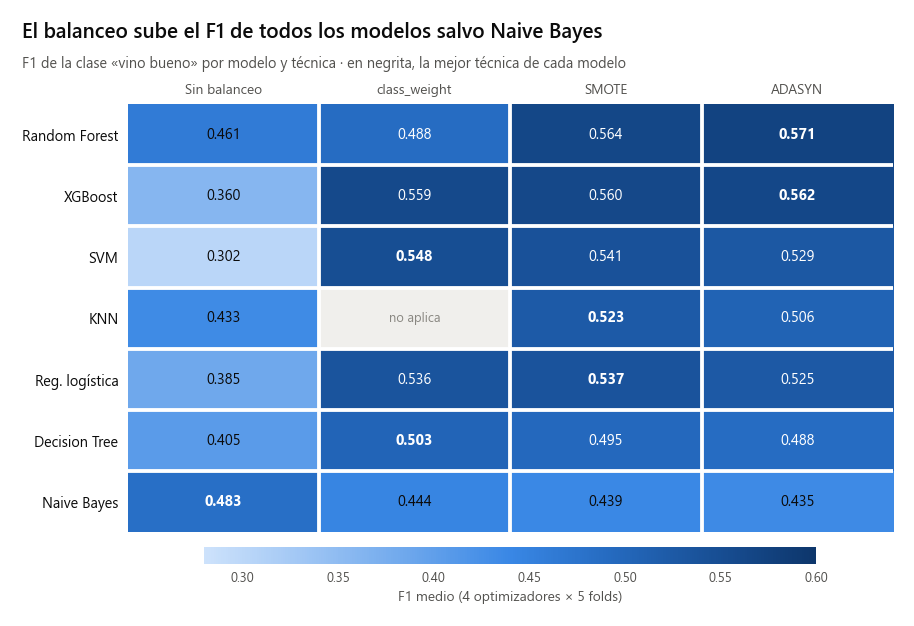

In [13]:
f1_por_modelo = (combos_clf.pivot_table(index="modelo", columns="balanceo", values="f1")
                 .reindex(index=ORDEN_CLF, columns=BALANCEOS))
f1_vista = f1_por_modelo.rename(index=corto, columns=ETIQUETA_BALANCEO)
maximo_fila = f1_vista.to_numpy() == f1_vista.max(axis=1).to_numpy()[:, None]

fig, ax = plt.subplots(figsize=(8, 4.8), layout="constrained")
norm = mcolors.Normalize(vmin=0.28, vmax=0.6)
mapa_calor(ax, f1_vista, CMAP_SECUENCIAL, norm, lambda v: f"{v:.3f}", negrita=maximo_fila)
barra_color(fig, ax, CMAP_SECUENCIAL, norm, "F1 medio (4 optimizadores × 5 folds)")
encabezado(fig, "El balanceo sube el F1 de todos los modelos salvo Naive Bayes",
           "F1 de la clase «vino bueno» por modelo y técnica · en negrita, la mejor técnica de cada modelo")
guardar(fig, "fig04_clf_balanceo_f1_por_modelo")
plt.show()

> **Resultado:** seis de los siete modelos mejoran su F1 con cualquier técnica; las ganancias más grandes son las de SVM (0.30 → 0.55) y XGBoost (0.36 → 0.56). La mejor técnica depende del modelo: `class_weight` para SVM y el árbol, SMOTE para KNN y la regresión logística, ADASYN para los dos ensambles. En Random Forest `class_weight` casi no ayuda (F1 0.49 frente a 0.57 con ADASYN; recall 0.41 frente a 0.66), probablemente porque sus árboles profundos terminan en hojas casi puras, donde el peso de la clase apenas cambia el voto. Naive Bayes es la excepción: sin balanceo ya tiene recall 0.67 y balancear solo le agrega falsos positivos.

In [14]:
tabla02 = (combos_clf.groupby(["modelo", "balanceo"])[["precision", "recall", "f1", "auc", "accuracy"]].mean()
           .round(4).reset_index())
guardar_tabla(tabla02, "tabla02_clf_balanceo_por_modelo")
guardar_tabla(efecto.round(4).rename_axis("balanceo").reset_index(), "tabla03_clf_efecto_balanceo")

recall_vista = (combos_clf.pivot_table(index="modelo", columns="balanceo", values="recall")
                .reindex(index=ORDEN_CLF, columns=BALANCEOS).rename(index=corto, columns=ETIQUETA_BALANCEO))
print("Recall medio por modelo y técnica:")
display(recall_vista.round(3))
print("Promedio de las cuatro técnicas (sin KNN):")
display(efecto.rename(index=ETIQUETA_BALANCEO, columns={**METRICAS_BALANCEO, "accuracy": "Accuracy"}).round(3))

Recall medio por modelo y técnica:


balanceo,Sin balanceo,class_weight,SMOTE,ADASYN
modelo,,,,
Random Forest,0.354,0.408,0.615,0.655
XGBoost,0.288,0.636,0.622,0.658
SVM,0.213,0.818,0.797,0.841
KNN,0.332,NaN,0.848,0.890
Reg. logística,0.291,0.788,0.786,0.825
Decision Tree,0.322,0.778,0.701,0.734
Naive Bayes,0.673,0.778,0.769,0.795


Promedio de las cuatro técnicas (sin KNN):


,Precisión,Recall,F1,AUC-ROC,Accuracy
balanceo,,,,,
Sin balanceo,0.537,0.357,0.399,0.822,0.813
class_weight,0.440,0.701,0.513,0.826,0.745
SMOTE,0.424,0.715,0.523,0.823,0.746
ADASYN,0.407,0.751,0.518,0.821,0.727


## 4. Regresión: predecir la nota de calidad

Mismo formato que la figura 1, ahora con RMSE (menos es mejor). La línea vertical es la **línea base** que siempre predice la media de `quality` del train: la distancia entre esa línea y cada modelo es el error que el modelo sí logra explicar.

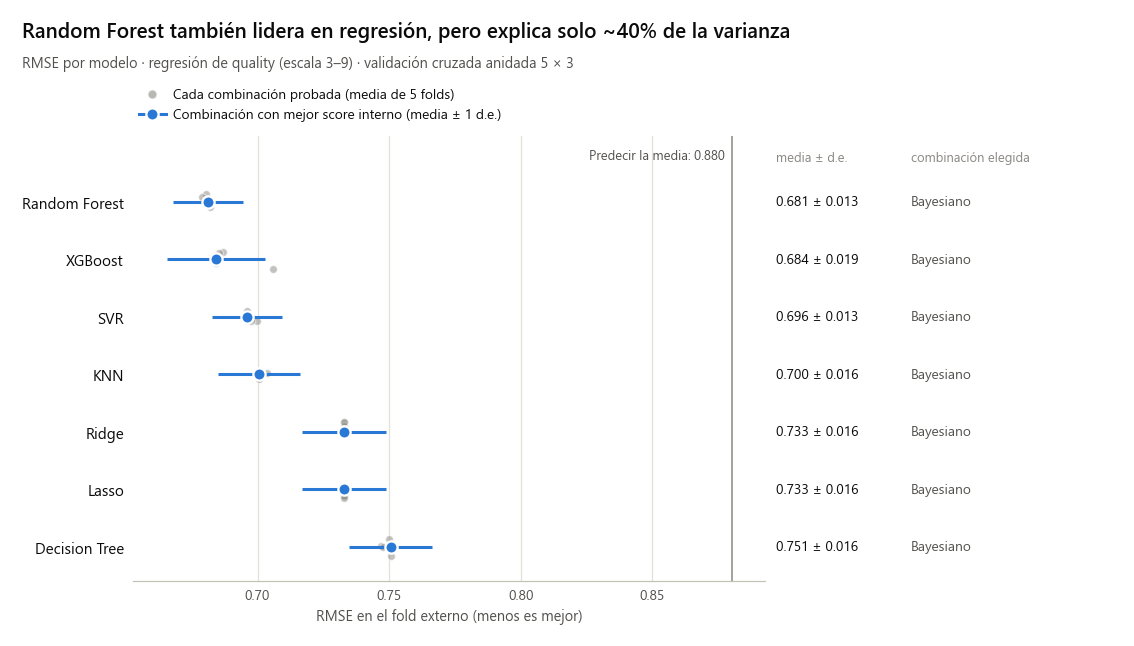

,Optimizador,RMSE,MAE,R²,Mejora vs. línea base,Seg. por fold
Modelo,,,,,,
Random Forest,Bayesiano,0.681 ± 0.013,0.526 ± 0.009,0.399 ± 0.009,22.6%,237
XGBoost,Bayesiano,0.684 ± 0.019,0.529 ± 0.013,0.393 ± 0.017,22.3%,298
SVR,Bayesiano,0.696 ± 0.013,0.532 ± 0.010,0.372 ± 0.012,20.9%,117
KNN,Bayesiano,0.700 ± 0.016,0.542 ± 0.014,0.364 ± 0.014,20.4%,14
Ridge,Bayesiano,0.733 ± 0.016,0.566 ± 0.005,0.304 ± 0.017,16.7%,3
Lasso,Bayesiano,0.733 ± 0.016,0.566 ± 0.005,0.304 ± 0.017,16.7%,3
Decision Tree,Bayesiano,0.751 ± 0.016,0.580 ± 0.009,0.270 ± 0.018,14.7%,4


In [15]:
fig, ax = grafico_por_modelo(combos_reg, elegidos_reg, "rmse", "RMSE en el fold externo (menos es mejor)",
                             lambda fila: fila["optimizador"], mayor_es_mejor=False,
                             referencia=(RMSE_BASE, f"Predecir la media: {RMSE_BASE:.3f}"))
encabezado(fig, "Random Forest también lidera en regresión, pero explica solo ~40% de la varianza",
           "RMSE por modelo · regresión de quality (escala 3–9) · validación cruzada anidada 5 × 3")
guardar(fig, "fig05_reg_rmse_por_modelo")
plt.show()

tabla04 = elegidos_reg[["modelo", "optimizador", "rmse", "rmse_std", "mae", "mae_std", "r2", "r2_std",
                        "score_interno", "tiempo_fold_s"]].round(4)
guardar_tabla(tabla04, "tabla04_reg_mejor_config_por_modelo")
display(pd.DataFrame({
    "Optimizador": elegidos_reg["optimizador"].to_numpy(),
    "RMSE": [mas_menos(m, s) for m, s in zip(elegidos_reg["rmse"], elegidos_reg["rmse_std"])],
    "MAE": [mas_menos(m, s) for m, s in zip(elegidos_reg["mae"], elegidos_reg["mae_std"])],
    "R²": [mas_menos(m, s) for m, s in zip(elegidos_reg["r2"], elegidos_reg["r2_std"])],
    "Mejora vs. línea base": [f"{1 - m / RMSE_BASE:.1%}" for m in elegidos_reg["rmse"]],
    "Seg. por fold": elegidos_reg["tiempo_fold_s"].round().astype(int).to_numpy(),
}, index=pd.Index(elegidos_reg["modelo"], name="Modelo")))

> **Resultado:** Random Forest obtiene el menor error (RMSE 0.681 ± 0.013, MAE 0.53, R² 0.40), un 23% menos que la línea base; XGBoost (0.684), SVR (0.696) y KNN (0.700) lo siguen de cerca. Los modelos lineales se estancan en R² 0.30 y el árbol individual en 0.27: la relación entre química y calidad no es lineal. Aun así, un MAE de 0.53 significa equivocarse en promedio por medio punto en una escala donde el 77% de los vinos tiene nota 5 o 6: el modelo sirve para ordenar vinos, no para predecir su nota exacta. El punto gris aislado de XGBoost (0.706) es Grid Search.

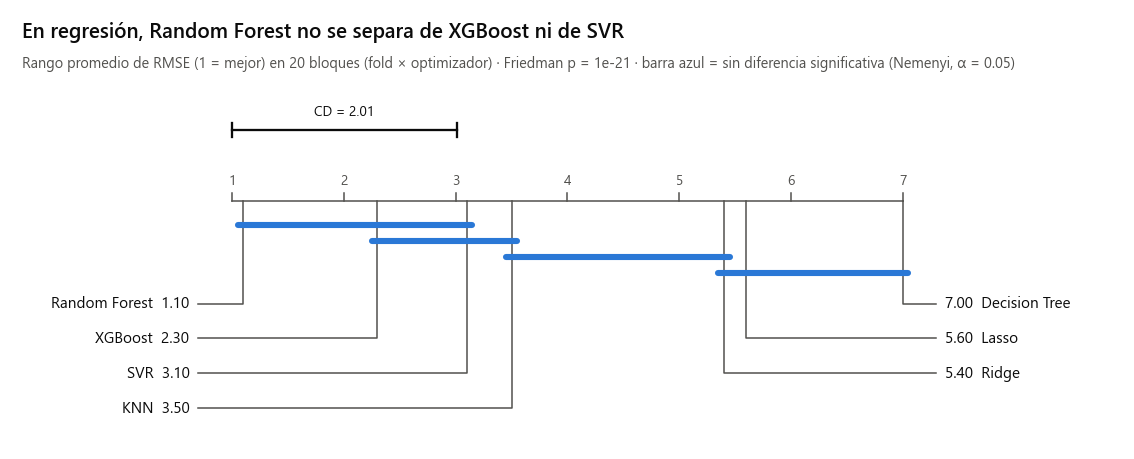

In [16]:
fr_modelos_reg = friedman_nemenyi(reg, "modelo", ["optimizador", "fold_externo"], "rmse", mayor_es_mejor=False)

fig, ax = plt.subplots(figsize=(10, 3.3), layout="constrained")
diagrama_cd(ax, fr_modelos_reg)
encabezado(fig, "En regresión, Random Forest no se separa de XGBoost ni de SVR",
           f"Rango promedio de RMSE (1 = mejor) en {fr_modelos_reg['N']} bloques (fold × optimizador) · "
           f"Friedman p = {fr_modelos_reg['p']:.0e} · barra azul = sin diferencia significativa (Nemenyi, α = 0.05)")
guardar(fig, "fig06_reg_cd_modelos")
plt.show()

> **Resultado:** con solo 20 bloques el test tiene menos potencia (CD = 2.01), pero Friedman sigue siendo contundente (p ≈ 10⁻²¹). Random Forest (rango 1.10) forma el grupo líder con XGBoost (2.30) y SVR (3.10) —este último justo en el límite: su diferencia de rango con Random Forest es 2.00 frente a una CD de 2.01— y es significativamente mejor que KNN, Ridge, Lasso y el árbol. Ridge y Lasso no se distinguen entre sí (el mejor Lasso casi no regulariza: alpha ≈ 0.001).

## 5. Métodos de optimización de hiperparámetros

Para aislar el efecto del optimizador, cada método se compara contra Grid Search **en el mismo modelo, balanceo y fold externo** (diferencia pareada) y luego se promedia. En azul, el método mejora a Grid Search; en rojo, empeora.

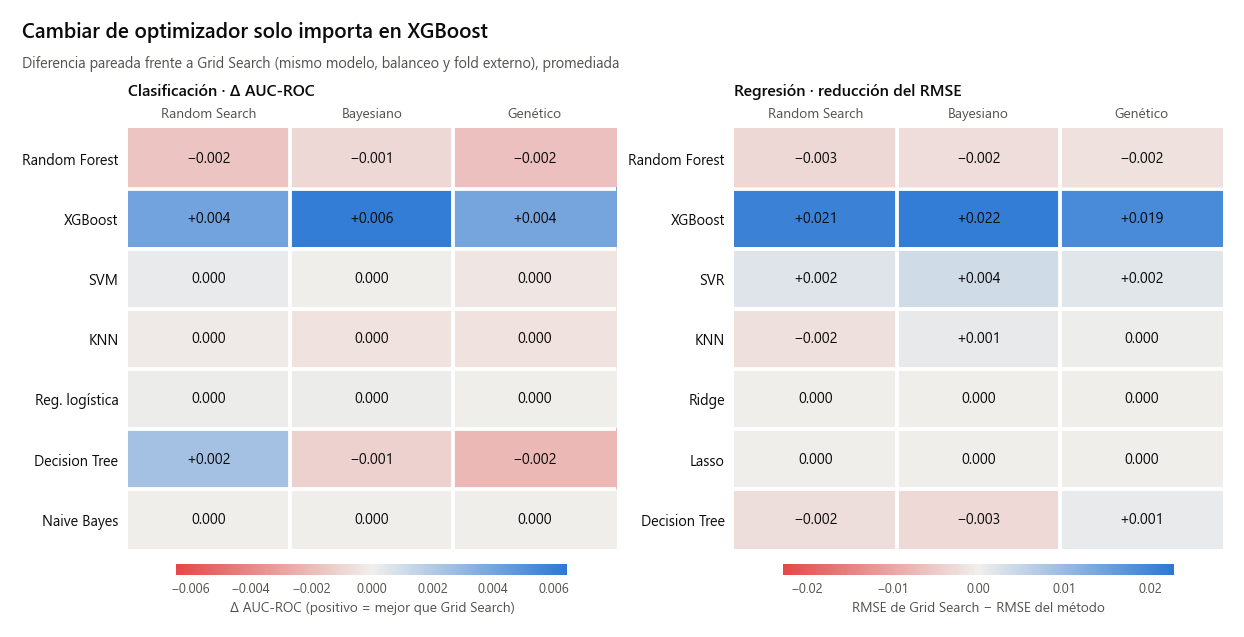

In [17]:
def mejora_vs_grid(df, metrica, mayor_es_mejor):
    claves = [c for c in ["modelo", "balanceo", "fold_externo"] if df[c].nunique() > 1]
    ancha = df.pivot_table(index=claves, columns="optimizador", values=metrica)
    signo = 1 if mayor_es_mejor else -1
    delta = ancha[OPTIMIZADORES[1:]].sub(ancha["Grid Search"], axis=0) * signo
    return delta.groupby("modelo").mean()


delta_clf = mejora_vs_grid(clf, "auc", True).reindex(ORDEN_CLF).rename(index=corto)
delta_reg = mejora_vs_grid(reg, "rmse", False).reindex(ORDEN_REG)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.9), layout="constrained")
for ax, delta, titulo, etiqueta in [
    (axes[0], delta_clf, "Clasificación · Δ AUC-ROC", "Δ AUC-ROC (positivo = mejor que Grid Search)"),
    (axes[1], delta_reg, "Regresión · reducción del RMSE", "RMSE de Grid Search − RMSE del método"),
]:
    tope = np.abs(delta.to_numpy()).max() * 1.05
    norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-tope, vmax=tope)
    mapa_calor(ax, delta, CMAP_DIVERGENTE, norm, lambda v: "0.000" if abs(v) < 5e-4 else f"{v:+.3f}".replace("-", "−"))
    ax.set_title(titulo)
    barra_color(fig, ax, CMAP_DIVERGENTE, norm, etiqueta)
encabezado(fig, "Cambiar de optimizador solo importa en XGBoost",
           "Diferencia pareada frente a Grid Search (mismo modelo, balanceo y fold externo), promediada")
guardar(fig, "fig07_optimizadores_mejora_vs_grid")
plt.show()

In [18]:
xgb = clf[clf["modelo"] == "XGBoost"].pivot_table(index=["balanceo", "fold_externo"], columns="optimizador", values="auc")
dif = xgb["Bayesiano"] - xgb["Grid Search"]
print(f"XGBoost (clasificación), Bayesiano − Grid Search: {dif.mean():+.4f} AUC; gana en {(dif > 0).sum()} de {len(dif)} "
      f"folds pareados (Wilcoxon p = {stats.wilcoxon(dif).pvalue:.1e})")
print("Hiperparámetros que eligió Grid Search para XGBoost (clasificación, SMOTE, fold 0):")
print("  ", clf.query("modelo == 'XGBoost' and balanceo == 'SMOTE' and optimizador == 'Grid Search' and fold_externo == 0")
      ["mejores_hiperparametros"].iloc[0])
print("Grid Search para Random Forest (regresión), folds 0–4:")
for texto in reg.query("modelo == 'Random Forest' and optimizador == 'Grid Search'").sort_values("fold_externo")["mejores_hiperparametros"]:
    print("  ", texto)

XGBoost (clasificación), Bayesiano − Grid Search: +0.0061 AUC; gana en 20 de 20 folds pareados (Wilcoxon p = 1.9e-06)
Hiperparámetros que eligió Grid Search para XGBoost (clasificación, SMOTE, fold 0):
   {'colsample_bytree': 0.5, 'learning_rate': 0.001, 'max_depth': 10, 'n_estimators': 500, 'subsample': 0.5}
Grid Search para Random Forest (regresión), folds 0–4:
   {'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}
   {'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}
   {'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}
   {'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}
   {'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}


> **Resultado:** solo XGBoost cambia de forma clara: los tres métodos le ganan a Grid Search tanto en clasificación (+0.004 a +0.006 de AUC) como en regresión (≈ 0.02 menos de RMSE); con Bayesiano, la mejora se repite en los 20 folds pareados de clasificación (Wilcoxon p ≈ 2·10⁻⁶). La causa es la dimensionalidad: con 5 hiperparámetros continuos, la grilla adaptativa solo alcanza 2 valores por hiperparámetro (2⁵ = 32 puntos) y ninguno cae cerca del óptimo. En clasificación, Grid Search eligió en los 20 folds `learning_rate = 0.001` con 500 árboles (un modelo muy conservador), y en regresión el extremo opuesto (`learning_rate = 0.3`, profundidad 2, 50 árboles). En el resto de los modelos las diferencias son de milésimas (±0.003) y cambian de signo: ruido.

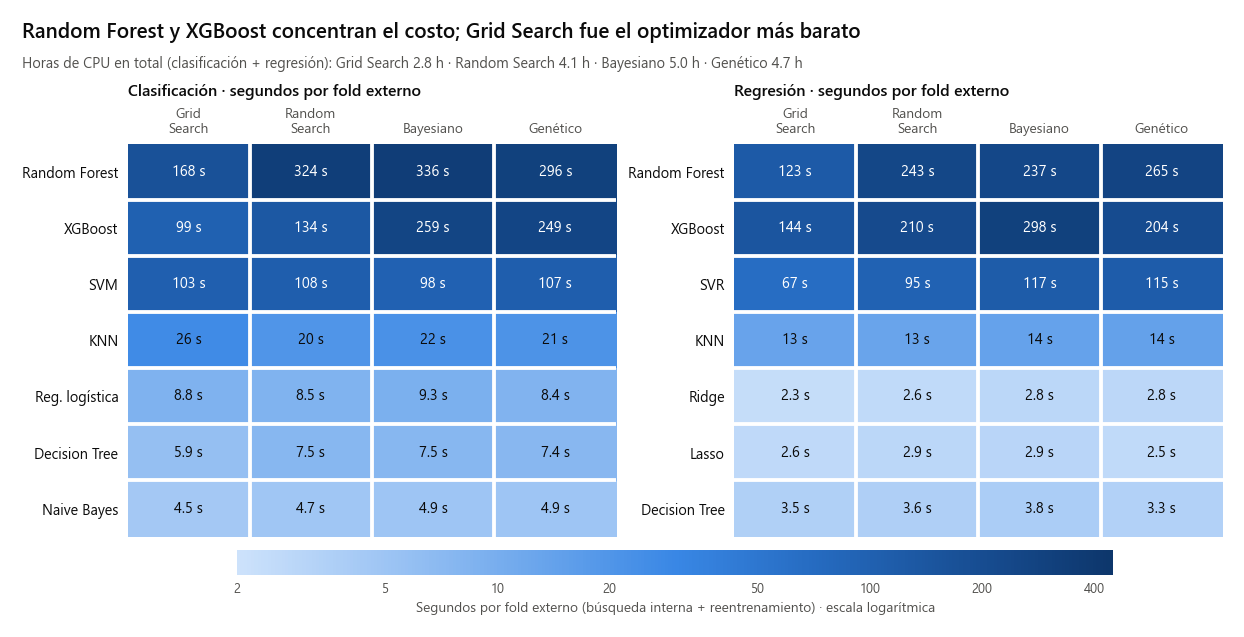

In [19]:
horas = pd.concat([clf, reg]).groupby("optimizador")["tiempo_seg"].sum() / 3600
tiempo_clf = clf.pivot_table(index="modelo", columns="optimizador", values="tiempo_seg").reindex(ORDEN_CLF)[OPTIMIZADORES]
tiempo_reg = reg.pivot_table(index="modelo", columns="optimizador", values="tiempo_seg").reindex(ORDEN_REG)[OPTIMIZADORES]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.9), layout="constrained")
norm = mcolors.LogNorm(vmin=2, vmax=450)
for ax, tiempo, tarea in [(axes[0], tiempo_clf.rename(index=corto), "Clasificación"), (axes[1], tiempo_reg, "Regresión")]:
    vista = tiempo.rename(columns=lambda o: o.replace(" ", "\n"))
    mapa_calor(ax, vista, CMAP_SECUENCIAL, norm, lambda v: f"{v:.0f} s" if v >= 10 else f"{v:.1f} s")
    ax.set_title(f"{tarea} · segundos por fold externo")
barra = barra_color(fig, axes, CMAP_SECUENCIAL, norm,
                    "Segundos por fold externo (búsqueda interna + reentrenamiento) · escala logarítmica")
barra.set_ticks([2, 5, 10, 20, 50, 100, 200, 400], labels=["2", "5", "10", "20", "50", "100", "200", "400"])
barra.ax.minorticks_off()
encabezado(fig, "Random Forest y XGBoost concentran el costo; Grid Search fue el optimizador más barato",
           "Horas de CPU en total (clasificación + regresión): " +
           " · ".join(f"{o} {horas[o]:.1f} h" for o in OPTIMIZADORES))
guardar(fig, "fig08_optimizadores_tiempo")
plt.show()

In [20]:
def victorias_score_interno(combos, claves):
    """Cuántas veces cada optimizador logró el mejor score interno medio, sin contar empates exactos."""
    ancha = combos.pivot_table(index=claves, columns="optimizador", values="score_interno").round(6)
    ganadores = ancha.eq(ancha.max(axis=1), axis=0)
    return ganadores[ganadores.sum(axis=1) == 1].sum().reindex(OPTIMIZADORES, fill_value=0).astype(int)


fr_opt_clf = friedman_nemenyi(clf, "optimizador", ["modelo", "balanceo", "fold_externo"], "auc")
fr_opt_reg = friedman_nemenyi(reg, "optimizador", ["modelo", "fold_externo"], "rmse", mayor_es_mejor=False)
victorias = victorias_score_interno(combos_clf, ["modelo", "balanceo"]) + victorias_score_interno(combos_reg, ["modelo"])
todos = pd.concat([clf, reg])
por_opt = todos.groupby("optimizador").agg(evals=("n_evaluaciones", "mean"), seg=("tiempo_seg", "sum"),
                                           n=("n_evaluaciones", "sum")).reindex(OPTIMIZADORES)

tabla05 = pd.DataFrame({
    "optimizador": OPTIMIZADORES,
    "auc_medio_clf": clf.groupby("optimizador")["auc"].mean().reindex(OPTIMIZADORES).to_numpy(),
    "rango_auc_clf": fr_opt_clf["rangos"].reindex(OPTIMIZADORES).to_numpy(),
    "rmse_medio_reg": reg.groupby("optimizador")["rmse"].mean().reindex(OPTIMIZADORES).to_numpy(),
    "rango_rmse_reg": fr_opt_reg["rangos"].reindex(OPTIMIZADORES).to_numpy(),
    "evaluaciones_por_busqueda": por_opt["evals"].to_numpy(),
    "segundos_por_evaluacion": (por_opt["seg"] / por_opt["n"]).to_numpy(),
    "horas_cpu_total": (por_opt["seg"] / 3600).to_numpy(),
    "veces_mejor_score_interno": victorias.to_numpy(),
}).round(4)
guardar_tabla(tabla05, "tabla05_optimizadores")
display(tabla05.set_index("optimizador").rename(columns={
    "auc_medio_clf": "AUC medio (clf)", "rango_auc_clf": "Rango AUC (clf)", "rmse_medio_reg": "RMSE medio (reg)",
    "rango_rmse_reg": "Rango RMSE (reg)", "evaluaciones_por_busqueda": "Evaluaciones por búsqueda",
    "segundos_por_evaluacion": "Seg. por evaluación", "horas_cpu_total": "Horas de CPU",
    "veces_mejor_score_interno": "Veces con mejor score interno",
}).round(3))
print(f"'Veces con mejor score interno': sobre {len(combos_clf.groupby(['modelo', 'balanceo']))} casos de clasificación "
      f"(modelo × balanceo) + {combos_reg['modelo'].nunique()} de regresión, sin contar empates exactos.")

,AUC medio (clf),Rango AUC (clf),RMSE medio (reg),Rango RMSE (reg),Evaluaciones por búsqueda,Seg. por evaluación,Horas de CPU,Veces con mejor score interno
optimizador,,,,,,,,
Grid Search,0.825,2.644,0.714,2.643,34.559,1.694,2.764,0
Random Search,0.826,2.393,0.712,2.500,40.000,2.190,4.136,0
Bayesiano,0.826,2.318,0.711,2.471,40.000,2.650,5.005,28
Genético,0.825,2.644,0.711,2.386,40.000,2.474,4.673,2


'Veces con mejor score interno': sobre 27 casos de clasificación (modelo × balanceo) + 7 de regresión, sin contar empates exactos.


> **Resultado:** Random Forest y XGBoost concentran casi todo el cómputo (100–340 s por fold, frente a menos de 10 s de los modelos lineales, el árbol y Naive Bayes). Grid Search fue el más barato (2.8 h de CPU frente a 4.1–5.0 h de los demás): evaluó menos puntos en los modelos con varios hiperparámetros (24 en Random Forest y 32 en XGBoost, en vez de 40) y cada evaluación le costó menos (1.7 s frente a 2.2–2.7 s), probablemente porque su grilla incluye configuraciones baratas que los métodos adaptativos descartan para concentrarse en zonas buenas —y caras— del espacio. Bayesiano fue el más caro, pero es el que mejor optimiza la validación interna: logró el mejor score interno en 28 de los 30 casos sin empate. Esa ventaja casi nunca se traslada al fold externo, salvo en XGBoost.

## 6. Resumen de las pruebas estadísticas

Los mismos tests de Friedman y Nemenyi aplicados a las otras dos decisiones del diseño: la técnica de balanceo (medida con F1, que es donde actúa) y el optimizador (medido con AUC, la métrica que optimiza la búsqueda).

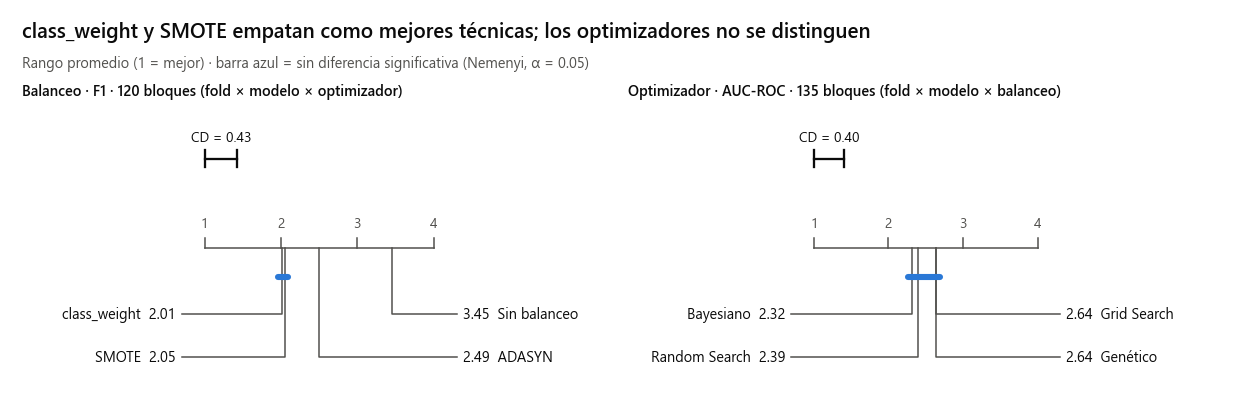

In [21]:
fr_balanceo_f1 = friedman_nemenyi(sin_knn, "balanceo", ["modelo", "optimizador", "fold_externo"], "f1")
fr_balanceo_auc = friedman_nemenyi(sin_knn, "balanceo", ["modelo", "optimizador", "fold_externo"], "auc")
fr_modelos_clf_f1 = friedman_nemenyi(clf[clf["balanceo"] != "class_weight"], "modelo",
                                     ["balanceo", "optimizador", "fold_externo"], "f1")

fig, axes = plt.subplots(1, 2, figsize=(11, 2.9), layout="constrained")
for ax, resultado, titulo in [
    (axes[0], fr_balanceo_f1, f"Balanceo · F1 · {fr_balanceo_f1['N']} bloques (fold × modelo × optimizador)"),
    (axes[1], fr_opt_clf, f"Optimizador · AUC-ROC · {fr_opt_clf['N']} bloques (fold × modelo × balanceo)"),
]:
    diagrama_cd(ax, resultado, fuente=9.5)
    ax.set_title(titulo, fontsize=9.5, pad=4)
encabezado(fig, "class_weight y SMOTE empatan como mejores técnicas; los optimizadores no se distinguen",
           "Rango promedio (1 = mejor) · barra azul = sin diferencia significativa (Nemenyi, α = 0.05)")
guardar(fig, "fig09_cd_balanceo_y_optimizadores")
plt.show()

In [22]:
pruebas = [
    ("Clasificación", "Modelos", "AUC-ROC", "fold × balanceo × optimizador (sin class_weight)", fr_modelos_clf),
    ("Clasificación", "Modelos", "F1", "fold × balanceo × optimizador (sin class_weight)", fr_modelos_clf_f1),
    ("Clasificación", "Balanceo", "F1", "fold × modelo × optimizador (sin KNN)", fr_balanceo_f1),
    ("Clasificación", "Balanceo", "AUC-ROC", "fold × modelo × optimizador (sin KNN)", fr_balanceo_auc),
    ("Clasificación", "Optimizador", "AUC-ROC", "fold × modelo × balanceo", fr_opt_clf),
    ("Regresión", "Modelos", "RMSE", "fold × optimizador", fr_modelos_reg),
    ("Regresión", "Optimizador", "RMSE", "fold × modelo", fr_opt_reg),
]
filas = []
for tarea, comparacion, metrica, bloques, r in pruebas:
    grupos = grupos_sin_diferencia(r["rangos"], r["cd"])
    nombres = [corto(n) for n in r["rangos"].index]
    filas.append({
        "tarea": tarea, "comparacion": comparacion, "metrica": metrica, "bloques": bloques,
        "N": r["N"], "k": r["k"], "chi2_friedman": round(r["chi2"], 2), "p_friedman": f"{r['p']:.1e}",
        "p_iman_davenport": f"{r['p_ID']:.1e}", "cd_nemenyi": round(r["cd"], 3),
        "ranking": " > ".join(f"{n} ({v:.2f})" for n, v in zip(nombres, r["rangos"])),
        "grupos_sin_diferencia": " | ".join(" = ".join(nombres[a:b + 1]) for a, b in grupos) or "ninguno",
    })
tabla06 = pd.DataFrame(filas)
guardar_tabla(tabla06, "tabla06_pruebas_friedman_nemenyi")
display(tabla06.drop(columns=["bloques"]))

,tarea,comparacion,metrica,N,k,chi2_friedman,p_friedman,p_iman_davenport,cd_nemenyi,ranking,grupos_sin_diferencia
0,Clasificación,Modelos,AUC-ROC,60,7,336.85,1.0e-69,1.6e-207,1.163,Random Forest (1.33) > XGBoost (1.72) > KNN (3.30) > SVM (3.92) > Reg. logística (4.80) > Decision Tree (5.93) > Naive Bayes (7.00),Random Forest = XGBoost | KNN = SVM | SVM = Reg. logística | Reg. logística = Decision Tree | Decision Tree = Naive Bayes
1,Clasificación,Modelos,F1,60,7,157.69,1.8e-31,1.5e-41,1.163,Random Forest (1.75) > XGBoost (2.30) > SVM (4.15) > KNN (4.45) > Reg. logística (4.65) > Naive Bayes (5.25) > Decision Tree (5.45),Random Forest = XGBoost | SVM = KNN = Reg. logística = Naive Bayes | KNN = Reg. logística = Naive Bayes = Decision Tree
2,Clasificación,Balanceo,F1,120,4,97.03,6.8e-21,3.6e-24,0.428,class_weight (2.01) > SMOTE (2.05) > ADASYN (2.49) > Sin balanceo (3.45),class_weight = SMOTE
3,Clasificación,Balanceo,AUC-ROC,120,4,67.01,1.9e-14,7.1e-16,0.428,class_weight (1.77) > Sin balanceo (2.46) > SMOTE (2.67) > ADASYN (3.10),Sin balanceo = SMOTE
4,Clasificación,Optimizador,AUC-ROC,135,4,8.48,3.7e-02,3.7e-02,0.404,Bayesiano (2.32) > Random Search (2.39) > Genético (2.64) > Grid Search (2.64),Bayesiano = Random Search = Genético = Grid Search
5,Regresión,Modelos,RMSE,20,7,110.91,1.3e-21,1.9e-61,2.014,Random Forest (1.10) > XGBoost (2.30) > SVR (3.10) > KNN (3.50) > Ridge (5.40) > Lasso (5.60) > Decision Tree (7.00),Random Forest = XGBoost = SVR | XGBoost = SVR = KNN | KNN = Ridge | Ridge = Lasso = Decision Tree
6,Regresión,Optimizador,RMSE,35,4,0.74,8.6e-01,8.7e-01,0.793,Genético (2.39) > Bayesiano (2.47) > Random Search (2.50) > Grid Search (2.64),Genético = Bayesiano = Random Search = Grid Search


> **Resultado:** en F1, `class_weight` (rango 2.01) y SMOTE (2.05) empatan como mejores técnicas; ADASYN (2.49) queda significativamente por debajo en el promedio de modelos —aunque es la mejor para los ensambles (figura 4)— y no balancear (3.45) es claramente lo peor. En AUC las diferencias entre técnicas son de milésimas (`class_weight` primera en rango, ADASYN última). Para los optimizadores, Friedman detecta una diferencia pequeña en clasificación (p = 0.037), pero Nemenyi no logra separar ningún par: los cuatro quedan en un mismo grupo. En regresión ni siquiera Friedman encuentra diferencias (p = 0.86).

## 7. ¿Es confiable la estimación? Score interno vs. externo

Si la búsqueda de hiperparámetros sobreajustara la validación interna, el score interno sería optimista: en clasificación los puntos quedarían **por debajo** de la diagonal (AUC externo < interno) y en regresión **por encima** (RMSE externo > interno).

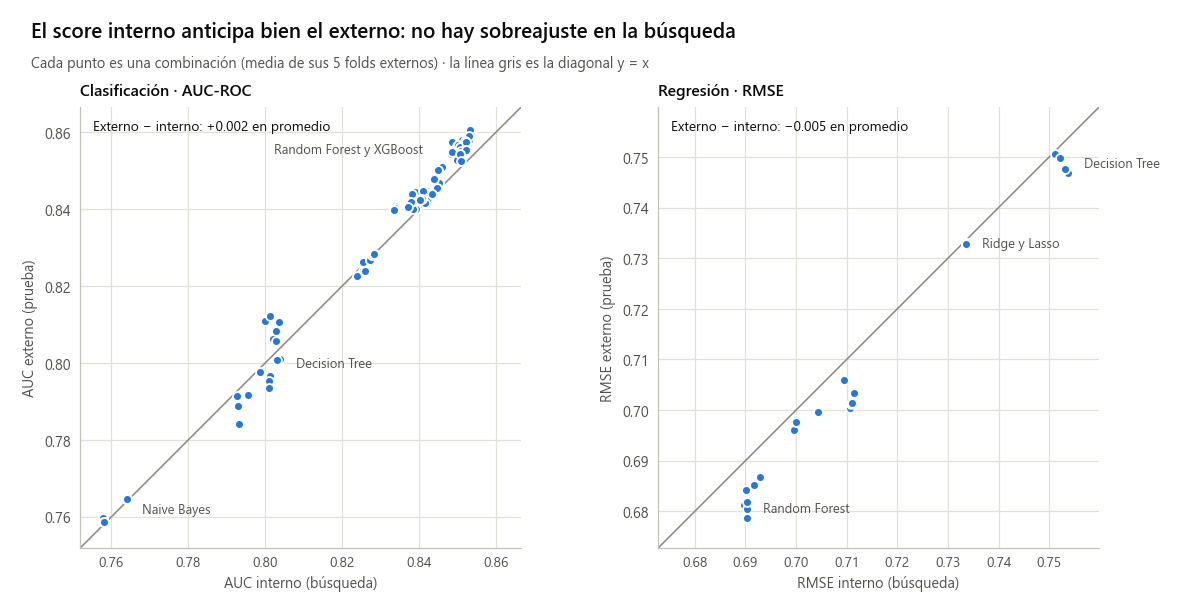

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.7), layout="constrained")
paneles = [
    (axes[0], combos_clf["score_interno"], combos_clf["auc"], combos_clf["modelo"], "Clasificación · AUC-ROC",
     "AUC interno (búsqueda)", "AUC externo (prueba)",
     [(["Naive Bayes"], "Naive Bayes", 1), (["Decision Tree"], "Decision Tree", 1),
      (["Random Forest", "XGBoost"], "Random Forest y XGBoost", -1)]),
    (axes[1], -combos_reg["score_interno"], combos_reg["rmse"], combos_reg["modelo"], "Regresión · RMSE",
     "RMSE interno (búsqueda)", "RMSE externo (prueba)",
     [(["Random Forest"], "Random Forest", 1), (["Ridge", "Lasso"], "Ridge y Lasso", 1),
      (["Decision Tree"], "Decision Tree", 1)]),
]
for ax, interno, externo, modelos, titulo, xlab, ylab, destacados in paneles:
    lim = [min(interno.min(), externo.min()) - 0.006, max(interno.max(), externo.max()) + 0.006]
    ax.plot(lim, lim, color=TINTA_3, lw=1, zorder=1)
    ax.scatter(interno, externo, s=34, color=AZUL, edgecolor=FONDO, linewidth=1.2, zorder=3)
    ax.set(xlim=lim, ylim=lim, xlabel=xlab, ylabel=ylab)
    ax.set_aspect("equal")
    ax.grid(True)
    ax.set_axisbelow(True)
    ax.set_title(titulo)
    diferencia = f"{np.mean(externo - interno):+.3f}".replace("-", "−")
    ax.text(0.03, 0.97, f"Externo − interno: {diferencia} en promedio",
            transform=ax.transAxes, ha="left", va="top", fontsize=9, color=TINTA)
    for grupo, texto, lado in destacados:       # lado: 1 = a la derecha del grupo, -1 = a la izquierda
        sel = modelos.isin(grupo)
        x = interno[sel].max() if lado > 0 else interno[sel].min()
        ax.annotate(texto, (x, externo[sel].mean()), xytext=(10 * lado, 0), textcoords="offset points",
                    ha="left" if lado > 0 else "right", va="center", fontsize=8.5, color=TINTA_2)
encabezado(fig, "El score interno anticipa bien el externo: no hay sobreajuste en la búsqueda",
           "Cada punto es una combinación (media de sus 5 folds externos) · la línea gris es la diagonal y = x")
guardar(fig, "fig10_score_interno_vs_externo")
plt.show()

> **Resultado:** los puntos siguen la diagonal: en promedio el AUC externo es 0.002 **mayor** que el interno y el RMSE externo 0.005 **menor**. La búsqueda de hiperparámetros no sobreajustó la validación interna; si acaso, el score interno es levemente pesimista, algo esperable porque cada modelo interno entrena con 2/3 del train externo (~2,840 vinos en lugar de ~4,260). Esto respalda que las métricas de este notebook son estimaciones honestas del rendimiento con vinos nuevos.

## 8. Configuración recomendada

Muchas combinaciones quedan dentro del ruido entre folds, así que elegir "la de mayor AUC" es sobreinterpretar decimales. Se usa la **regla de un error estándar**: son candidatas todas las combinaciones cuya métrica principal está a menos de 1 error estándar (d.e. / √5) de la mejor, y entre ellas se desempata con un criterio secundario:

* **Clasificación:** métrica principal AUC-ROC (la que optimizó la búsqueda); desempate por **F1**, porque el objetivo práctico es detectar vinos buenos con el umbral por defecto.
* **Regresión:** métrica principal RMSE; como RMSE y MAE se mueven juntos, se desempata por **menor tiempo de cómputo**.

In [24]:
mejor_auc = combos_clf.loc[combos_clf["auc"].idxmax()]
umbral_auc = mejor_auc["auc"] - mejor_auc["auc_std"] / np.sqrt(config.K_OUTER)
candidatas_clf = combos_clf[combos_clf["auc"] >= umbral_auc].sort_values("f1", ascending=False)
recomendada_clf = candidatas_clf.iloc[0]

mejor_rmse = combos_reg.loc[combos_reg["rmse"].idxmin()]
umbral_rmse = mejor_rmse["rmse"] + mejor_rmse["rmse_std"] / np.sqrt(config.K_OUTER)
candidatas_reg = combos_reg[combos_reg["rmse"] <= umbral_rmse].sort_values("tiempo_fold_s")
recomendada_reg = candidatas_reg.iloc[0]

print(f"Clasificación: mejor AUC = {mejor_auc['auc']:.4f} → candidatas con AUC ≥ {umbral_auc:.4f}: {len(candidatas_clf)}")
display(pd.DataFrame({
    "Modelo": candidatas_clf["modelo"].map(corto).to_numpy(),
    "Balanceo": candidatas_clf["balanceo"].map(ETIQUETA_BALANCEO).to_numpy(),
    "Optimizador": candidatas_clf["optimizador"].to_numpy(),
    "AUC-ROC": [mas_menos(m, s) for m, s in zip(candidatas_clf["auc"], candidatas_clf["auc_std"])],
    "F1": candidatas_clf["f1"].round(3).to_numpy(),
    "Recall": candidatas_clf["recall"].round(3).to_numpy(),
    "Precisión": candidatas_clf["precision"].round(3).to_numpy(),
    "Seg. por fold": candidatas_clf["tiempo_fold_s"].round().astype(int).to_numpy(),
}).head(10))
guardar_tabla(candidatas_clf.round(4), "tabla07_clf_candidatas_1se")

print(f"\nRegresión: mejor RMSE = {mejor_rmse['rmse']:.4f} → candidatas con RMSE ≤ {umbral_rmse:.4f}: {len(candidatas_reg)}")
display(pd.DataFrame({
    "Modelo": candidatas_reg["modelo"].to_numpy(),
    "Optimizador": candidatas_reg["optimizador"].to_numpy(),
    "RMSE": [mas_menos(m, s) for m, s in zip(candidatas_reg["rmse"], candidatas_reg["rmse_std"])],
    "MAE": candidatas_reg["mae"].round(3).to_numpy(),
    "R²": candidatas_reg["r2"].round(3).to_numpy(),
    "Seg. por fold": candidatas_reg["tiempo_fold_s"].round().astype(int).to_numpy(),
}))

Clasificación: mejor AUC = 0.8605 → candidatas con AUC ≥ 0.8537: 26


,Modelo,Balanceo,Optimizador,AUC-ROC,F1,Recall,Precisión,Seg. por fold
0,Random Forest,ADASYN,Random Search,0.855 ± 0.018,0.575,0.671,0.504,431
1,Random Forest,ADASYN,Genético,0.855 ± 0.018,0.573,0.660,0.507,400
2,Random Forest,ADASYN,Bayesiano,0.856 ± 0.017,0.568,0.658,0.502,429
3,Random Forest,ADASYN,Grid Search,0.857 ± 0.018,0.568,0.629,0.518,222
4,XGBoost,ADASYN,Genético,0.854 ± 0.017,0.566,0.667,0.495,318
5,Random Forest,SMOTE,Grid Search,0.858 ± 0.016,0.566,0.602,0.535,219
6,XGBoost,SMOTE,Genético,0.857 ± 0.015,0.566,0.600,0.540,386
7,XGBoost,ADASYN,Random Search,0.855 ± 0.021,0.566,0.649,0.502,231
8,Random Forest,SMOTE,Random Search,0.856 ± 0.015,0.565,0.628,0.514,426
9,Random Forest,SMOTE,Genético,0.857 ± 0.015,0.562,0.618,0.517,345



Regresión: mejor RMSE = 0.6787 → candidatas con RMSE ≤ 0.6853: 6


,Modelo,Optimizador,RMSE,MAE,R²,Seg. por fold
0,Random Forest,Grid Search,0.679 ± 0.015,0.523,0.403,123
1,XGBoost,Random Search,0.685 ± 0.012,0.528,0.392,210
2,Random Forest,Bayesiano,0.681 ± 0.013,0.526,0.399,237
3,Random Forest,Random Search,0.682 ± 0.014,0.526,0.398,243
4,Random Forest,Genético,0.680 ± 0.014,0.524,0.400,265
5,XGBoost,Bayesiano,0.684 ± 0.019,0.529,0.393,298


In [25]:
def detalle_por_fold(df, fila, metricas):
    filtro = (df["modelo"] == fila["modelo"]) & (df["optimizador"] == fila["optimizador"])
    if "balanceo" in fila.index:
        filtro &= df["balanceo"] == fila["balanceo"]
    return df.loc[filtro, ["fold_externo", *metricas, "mejores_hiperparametros"]].sort_values("fold_externo").round(4)


print(f"Clasificación → {recomendada_clf['modelo']} + {recomendada_clf['balanceo']} + {recomendada_clf['optimizador']}")
folds_clf = detalle_por_fold(clf, recomendada_clf, ["auc", "f1", "recall", "precision"])
display(folds_clf.set_index("fold_externo"))
print(f"Regresión → {recomendada_reg['modelo']} + {recomendada_reg['optimizador']}")
folds_reg_rec = detalle_por_fold(reg, recomendada_reg, ["rmse", "mae", "r2"])
display(folds_reg_rec.set_index("fold_externo"))
guardar_tabla(pd.concat([folds_clf.assign(tarea="clasificacion"), folds_reg_rec.assign(tarea="regresion")]),
              "tabla08_hiperparametros_config_recomendada")

Clasificación → Random Forest + ADASYN + Random Search


,auc,f1,recall,precision,mejores_hiperparametros
fold_externo,,,,,
0,0.8825,0.6327,0.7413,0.5519,"{'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 324}"
1,0.8423,0.5614,0.6337,0.5039,"{'max_depth': 22, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 253}"
2,0.8439,0.5600,0.6238,0.5081,"{'max_depth': 24, 'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 457}"
3,0.8426,0.5354,0.6733,0.4444,"{'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 4, 'n_estimators': 404}"
4,0.8630,0.5860,0.6832,0.5130,"{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 458}"


Regresión → Random Forest + Grid Search


,rmse,mae,r2,mejores_hiperparametros
fold_externo,,,,
0,0.6592,0.5080,0.4220,"{'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}"
1,0.6683,0.5211,0.4082,"{'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}"
2,0.6830,0.5194,0.3892,"{'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}"
3,0.6870,0.5304,0.3946,"{'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}"
4,0.6960,0.5343,0.4022,"{'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}"


## 9. Conclusiones

1. **El tipo de modelo es la decisión que más pesa.** Los ensambles de árboles lideran las dos tareas. En clasificación, Random Forest (AUC 0.860 ± 0.015) y XGBoost (0.857 ± 0.013) comparten el primer lugar según Friedman–Nemenyi y superan de forma significativa a SVM, KNN, regresión logística, árbol de decisión y Naive Bayes. En regresión, Random Forest logra el menor error (RMSE 0.68, R² ≈ 0.40), estadísticamente empatado con XGBoost y SVR. La brecha frente a los modelos lineales (AUC 0.83; R² 0.30) confirma lo que anticipaba el EDA: la relación entre la química del vino y su calidad no es lineal.

2. **Balancear no mejora la discriminación, pero sí la detección de vinos buenos.** Ninguna técnica mueve el AUC (0.82–0.83), porque el AUC no depende del umbral. Lo que cambia es el punto de operación: el recall de los vinos buenos pasa de 0.36 a 0.70–0.75 y el F1 de 0.40 a 0.51–0.52, a costa de precisión (0.54 → 0.41–0.44). En promedio, `class_weight` y SMOTE empatan como mejores técnicas, pero la mejor depende del modelo: en Random Forest y XGBoost rinde más el sobremuestreo (ADASYN), y en Naive Bayes es mejor no balancear.

3. **El optimizador casi no importa, salvo cuando el espacio de búsqueda es grande y sensible.** Con 40 evaluaciones, los cuatro métodos llegan al mismo rendimiento externo (Nemenyi no separa ningún par; en regresión, Friedman p = 0.86). La excepción es XGBoost, con 5 hiperparámetros continuos: la grilla solo alcanza 2 valores por hiperparámetro y Grid Search queda lejos del óptimo, mientras que Bayesiano lo supera en todos los folds pareados (20 de 20 en clasificación y 5 de 5 en regresión; +0.006 de AUC y −0.022 de RMSE). Grid Search fue el más barato (2.8 h de CPU frente a 4.1–5.0 h), pero es el único que falla cuando el espacio crece. La optimización bayesiana (TPE) es la opción más segura por defecto: obtuvo el mejor score interno en 28 de 30 casos, nunca perdió más de 0.003 frente a Grid Search y fue la que más ganó en XGBoost.

4. **Las estimaciones son confiables.** El score interno anticipa el externo (diferencia media de +0.002 en AUC y −0.005 en RMSE), así que la búsqueda no sobreajustó la validación interna. Además, los resultados coinciden con el modelado preliminar del EDA (Random Forest: AUC 0.86 y R² 0.39): la optimización intensiva no movió el techo de rendimiento; lo que sí aportó fue el balanceo, que en Random Forest sube el F1 de 0.46 a 0.57 con ADASYN (figura 4).

5. **Configuraciones recomendadas** (regla de 1 error estándar):

| Tarea | Configuración | Rendimiento en el fold externo |
|---|---|---|
| Clasificación (`quality ≥ 7`) | Random Forest + ADASYN, optimizado con Random Search | AUC 0.855 ± 0.018 · F1 0.575 · recall 0.67 · precisión 0.50 |
| Regresión (`quality`) | Random Forest, optimizado con Grid Search | RMSE 0.679 ± 0.015 · MAE 0.52 · R² 0.40 |

Las cuatro variantes de Random Forest + ADASYN ocupan los cuatro primeros lugares por F1, así que la recomendación no depende del optimizador: con Grid Search se obtiene casi lo mismo (F1 0.568) en la mitad del tiempo.

